<a href="https://colab.research.google.com/github/gakbn/ESCB-AngelGabrielAndradeAmezcua/blob/main/Lab15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio SHP: Clasificación de Cáncer de Mama
# Implementación con Árbol de Decisión CART

**Dataset:** Breast Cancer Wisconsin (Diagnostic)

**Objetivo:** Clasificar tumores como malignos o benignos basándose en características de células nucleares usando el algoritmo CART.

In [1]:
# Importamos bibliotecas
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.datasets import load_breast_cancer

In [3]:
# Cargamos el DataSet de cáncer de mama
cancer = load_breast_cancer(as_frame=True)

In [4]:
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [5]:
dfCancer = cancer.frame

In [6]:
dfCancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Exploración del conjunto de datos

En esta sección analizamos la estructura y características principales del dataset de cáncer de mama para comprender mejor los datos antes de entrenar el modelo.

In [7]:
dfCancer.shape

(569, 31)

In [8]:
dfCancer.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [9]:
# Clases objetivo (0 = Maligno, 1 = Benigno)
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [10]:
# Renombrar la columna "target"
dfCancer.rename(columns={"target" : "diagnostico"}, inplace = True)

In [11]:
dfCancer["diagnostico"] = dfCancer["diagnostico"].map({
    0: "maligno",
    1: "benigno"
})

In [12]:
dfCancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,maligno
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,maligno
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,maligno
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,maligno
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,maligno


In [13]:
dfCancer.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,maligno
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,maligno
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,maligno
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,maligno
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,benigno


## Identificar variables predictoras y variables objetivo

**Variables predictoras (X):** Las 30 características numéricas que describen las propiedades de los núcleos celulares (radio, textura, perímetro, área, compacidad, concavidad, etc.)

**Variable objetivo (y):** La clase del tumor (maligno o benigno)

In [14]:
# Variables predictoras
X = dfCancer.drop(columns=["diagnostico"])

In [15]:
print("Variables predictoras")
print(X.columns.tolist())

Variables predictoras
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


In [16]:
# Variable objetivo
y = dfCancer["diagnostico"]

In [17]:
print("Variable objetivo")
print(y.name)

Variable objetivo
diagnostico


## Importancia de las variables

El árbol de decisión CART calcula la importancia de cada variable basándose en cuánto reduce la impureza (índice de Gini). Las variables más importantes son las que aparecen en los nodos superiores del árbol, ya que son las que mejor separan las clases.

**Interpretación:**
- Una importancia mayor a 0 indica que la variable contribuye a la clasificación
- Las variables con importancia 0 no se utilizaron en el árbol
- La suma de todas las importancias es igual a 1

In [18]:
# Entrenamos un árbol preliminar para ver importancia de variables
arbol_preliminar = DecisionTreeClassifier(random_state=42, max_depth=5)
arbol_preliminar.fit(X, y)

DecisionTreeClassifier(max_depth=5, random_state=42)

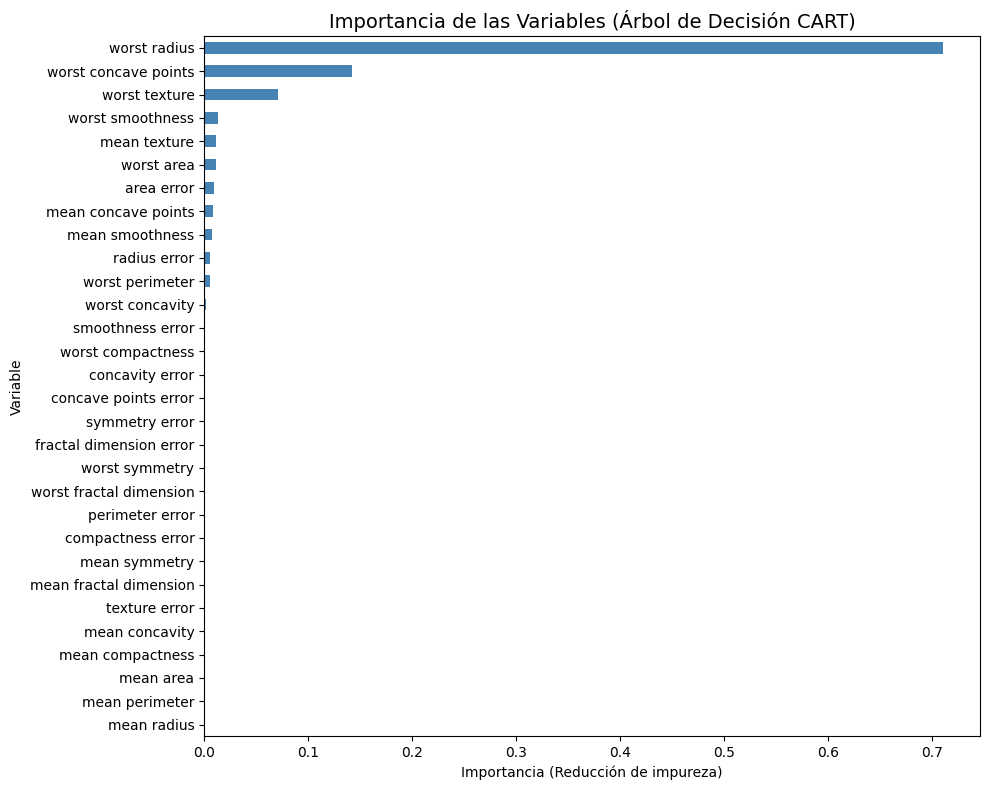

In [19]:
# Gráfica de importancia de variables
importancias = pd.Series(arbol_preliminar.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importancias.plot(kind='barh', color='steelblue')
plt.title('Importancia de las Variables (Árbol de Decisión CART)', fontsize=14)
plt.xlabel('Importancia (Reducción de impureza)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

In [20]:
# Top 10 variables más importantes
print("Top 10 variables más importantes:")
print(importancias.tail(10))

Top 10 variables más importantes:
radius error            0.005955
mean smoothness         0.007166
mean concave points     0.008958
area error              0.009560
worst area              0.011322
mean texture            0.011517
worst smoothness        0.013304
worst texture           0.071275
worst concave points    0.141894
worst radius            0.710391
dtype: float64


## Dividir los datos en prueba y entrenamiento

**Configuración de la división:**
- **Proporción:** 80% entrenamiento (455 muestras), 20% prueba (114 muestras)
- **Random state (semilla):** 42 para garantizar reproducibilidad de los resultados
- **Estratificación:** Sí, se utiliza `stratify=y` para mantener la proporción de clases (maligno/benigno) en ambos conjuntos

**Evitar fuga de información:**
- Se aplica `fit_transform` solo en el conjunto de entrenamiento
- Se aplica `transform` en el conjunto de prueba
- Esto asegura que el modelo no tenga acceso a información del conjunto de prueba durante el entrenamiento

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [22]:
print("X_train: " , X_train.shape)
print("X_test: " , X_test.shape)
print("y_train: " , y_train.shape)
print("y_test: " , y_test.shape)

X_train:  (455, 30)
X_test:  (114, 30)
y_train:  (455,)
y_test:  (114,)


In [23]:
# Verificar estratificación
print("Distribución de clases en entrenamiento:")
print(y_train.value_counts(normalize=True))
print("\nDistribución de clases en prueba:")
print(y_test.value_counts(normalize=True))

Distribución de clases en entrenamiento:
diagnostico
benigno    0.626374
maligno    0.373626
Name: proportion, dtype: float64

Distribución de clases en prueba:
diagnostico
benigno    0.631579
maligno    0.368421
Name: proportion, dtype: float64


## Entrenamiento del modelo Árbol de Decisión CART

El algoritmo **CART** (Classification and Regression Trees) es un método de aprendizaje supervisado que construye un árbol de decisión binario para clasificación.

**Parámetros del modelo:**
- `criterion='gini'`: Utiliza el índice de Gini para medir la impureza de los nodos
- `max_depth=5`: Profundidad máxima del árbol (evita sobreajuste)
- `min_samples_split=10`: Mínimo de muestras requeridas para dividir un nodo interno
- `random_state=42`: Semilla para reproducibilidad

**Ventajas de CART:**
- No requiere escalado de variables
- Fácil de interpretar y visualizar
- Maneja tanto variables numéricas como categóricas

In [24]:
modelo = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

In [25]:
modelo.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

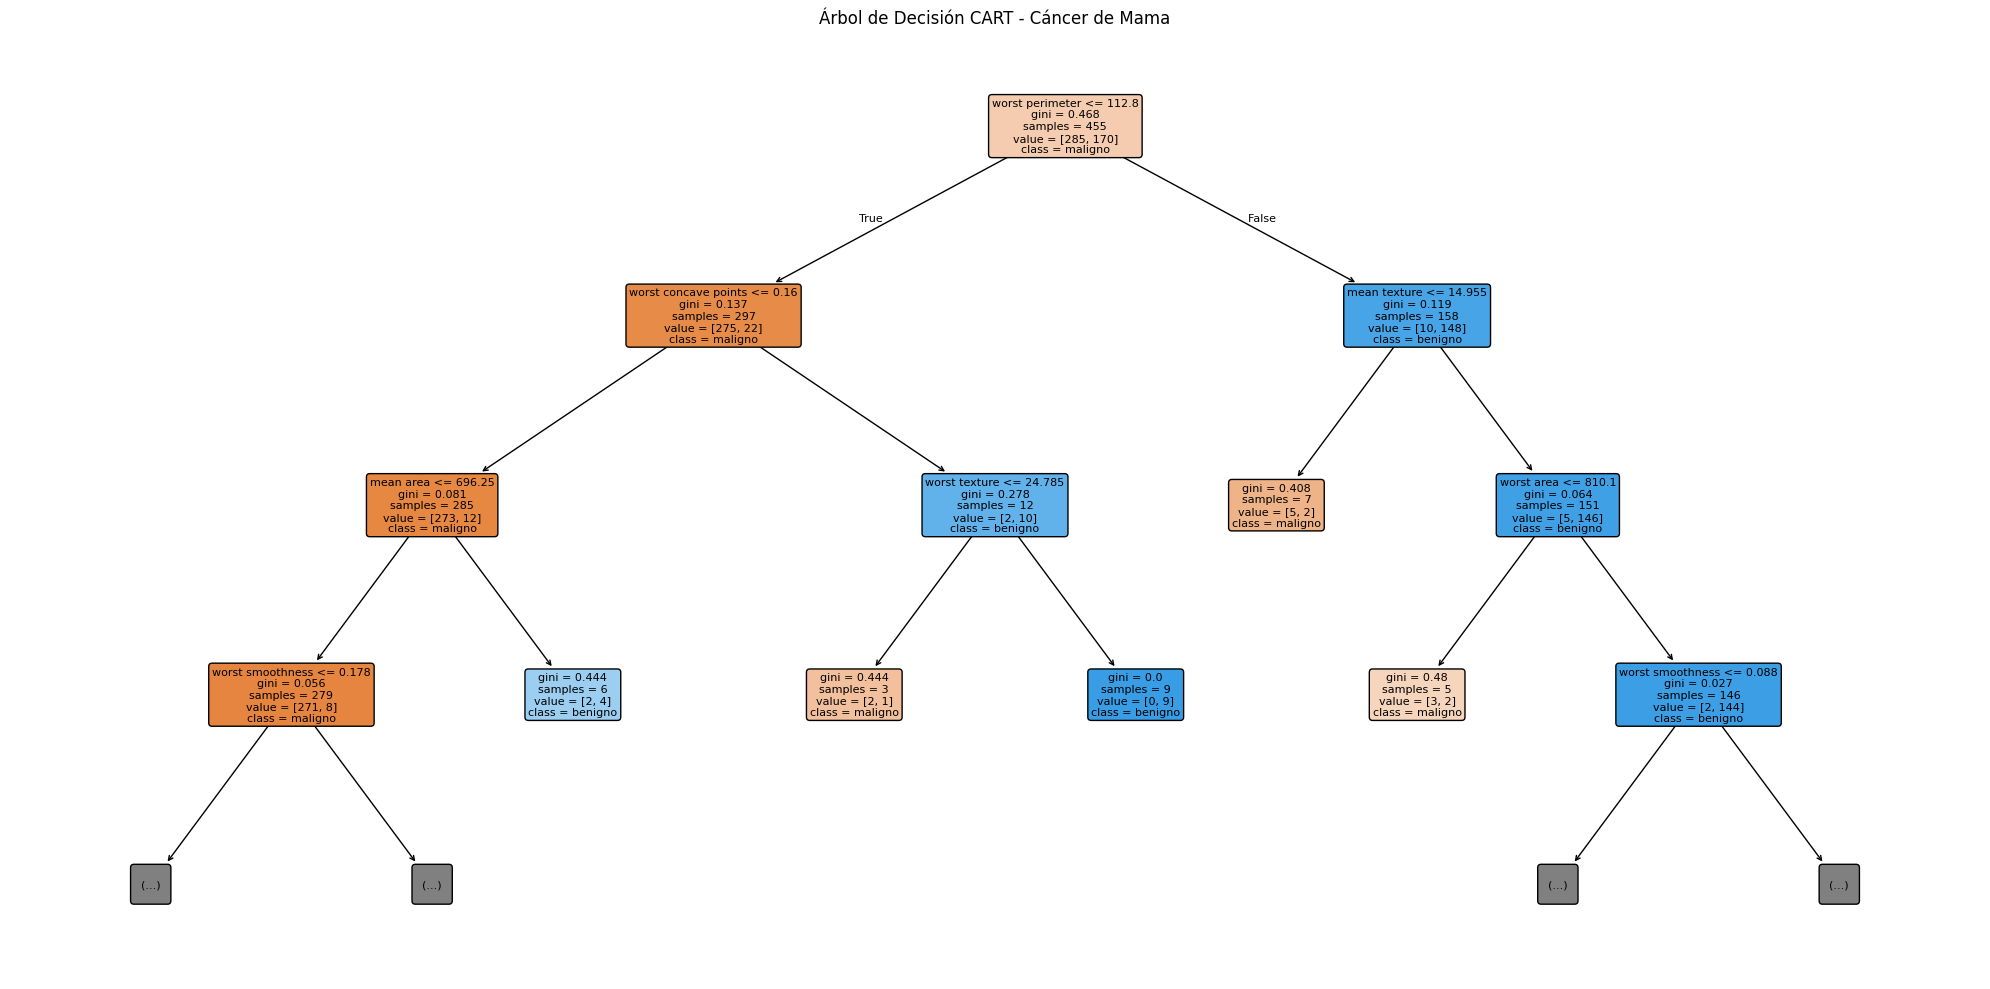

In [26]:
# Visualización del árbol de decisión
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(modelo,
          feature_names=X.columns,
          class_names=["maligno", "benigno"],
          filled=True,
          rounded=True,
          ax=ax,
          max_depth=3,
          fontsize=8)
plt.title('Árbol de Decisión CART - Cáncer de Mama')
plt.tight_layout()
plt.show()

## Realizamos predicciones con las variables de prueba

Una vez entrenado el modelo, utilizamos el conjunto de prueba (que el modelo nunca ha visto) para evaluar su capacidad de generalización.

In [27]:
prediccion = modelo.predict(X_test)

In [28]:
print(prediccion[:10])

['benigno' 'maligno' 'maligno' 'benigno' 'benigno' 'benigno' 'maligno'
 'maligno' 'benigno' 'benigno']


In [29]:
# Comparación entre valores reales y valores predichos
comparacion = pd.DataFrame({
    "diagnostico real": y_test.values,
    "diagnostico predicho": prediccion
})

In [30]:
comparacion.head(10)

,diagnostico real,diagnostico predicho
0,benigno,benigno
1,maligno,maligno
2,benigno,maligno
3,maligno,benigno
4,benigno,benigno
5,benigno,benigno
6,maligno,maligno
7,benigno,maligno
8,benigno,benigno
9,benigno,benigno


## Evaluación del modelo

Utilizamos múltiples métricas para evaluar el desempeño del modelo de clasificación:

| Métrica | Descripción |
|---------|-------------|
| **Accuracy** | Proporción de predicciones correctas sobre el total |
| **Precision** | De los predichos como benignos, cuántos realmente lo son |
| **Recall** | De los que realmente son benignos, cuántos detecté correctamente |
| **F1-Score** | Media armónica entre precision y recall |
| **Matriz de confusión** | Muestra VP, FP, VN, FN |

**Interpretación para diagnóstico médico:**
- **Alto Recall** es importante para no perder casos malignos
- **Alta Precisión** reduce falsos positivos (pacientes sanos diagnosticados como enfermos)

In [31]:
accuracy = accuracy_score(y_test, prediccion)
print(f"Accuracy/exactitud: {accuracy: .4f}")

Accuracy/exactitud:  0.8947


In [32]:
# Matriz de confusión
cm = confusion_matrix(y_test, prediccion)

In [33]:
cm_df = pd.DataFrame(
    cm,
    index = modelo.classes_,
    columns = modelo.classes_
)
cm_df

,benigno,maligno
benigno,69,3
maligno,9,33


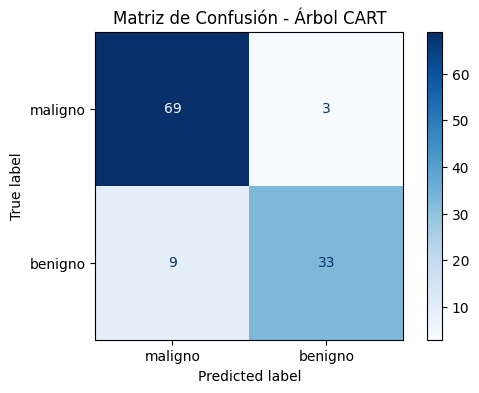

In [34]:
# Gráfica de la matriz de confusión
fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["maligno", "benigno"])
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - Árbol CART')
plt.show()

# Classification report
proporciona metricas que permiten evaluar el desempeño de cada clase: precision, recall, f1-score, support

In [35]:
print(classification_report(y_test, prediccion))

              precision    recall  f1-score   support

     benigno       0.88      0.96      0.92        72
     maligno       0.92      0.79      0.85        42

    accuracy                           0.89       114
   macro avg       0.90      0.87      0.88       114
weighted avg       0.90      0.89      0.89       114



## Implementación con datos nuevos

Probaremos el modelo con datos ficticios de un paciente nuevo para demostrar cómo se utilizaría en un entorno real.

**Formato de entrada:**
- Se requiere un DataFrame con las mismas 30 características que el dataset original
- Los datos deben estar en el mismo orden que las columnas de entrenamiento
- No se necesita escalado ya que CART no lo requiere

In [36]:
# Datos nuevos de ejemplo (valores basados en estadísticas del dataset)
# Formato: las mismas 30 características en el mismo orden
datos_nuevos = pd.DataFrame({
    'mean radius': [14.5],
    'mean texture': [18.0],
    'mean perimeter': [93.0],
    'mean area': [650.0],
    'mean smoothness': [0.095],
    'mean compactness': [0.08],
    'mean concavity': [0.06],
    'mean concave points': [0.04],
    'mean symmetry': [0.18],
    'mean fractal dimension': [0.06],
    'radius error': [0.4],
    'texture error': [1.0],
    'perimeter error': [3.0],
    'area error': [40.0],
    'smoothness error': [0.007],
    'compactness error': [0.02],
    'concavity error': [0.02],
    'concave points error': [0.01],
    'symmetry error': [0.015],
    'fractal dimension error': [0.003],
    'worst radius': [16.0],
    'worst texture': [24.0],
    'worst perimeter': [105.0],
    'worst area': [880.0],
    'worst smoothness': [0.12],
    'worst compactness': [0.15],
    'worst concavity': [0.14],
    'worst concave points': [0.07],
    'worst symmetry': [0.28],
    'worst fractal dimension': [0.07]
})

In [37]:
print("Datos nuevos de entrada:")
print(f"Forma: {datos_nuevos.shape}")
print(f"\nPrimeras características:")
print(datos_nuevos.iloc[0, :10])

Datos nuevos de entrada:
Forma: (1, 30)

Primeras características:
mean radius                14.500
mean texture               18.000
mean perimeter             93.000
mean area                 650.000
mean smoothness             0.095
mean compactness            0.080
mean concavity              0.060
mean concave points         0.040
mean symmetry               0.180
mean fractal dimension      0.060
Name: 0, dtype: float64


In [38]:
# Predicción con el modelo CART
prediccion_nueva = modelo.predict(datos_nuevos)
probabilidad_nueva = modelo.predict_proba(datos_nuevos)

print("Predicción Árbol de Decisión CART:")
print(f"Resultado: {prediccion_nueva[0]}")
print(f"Probabilidad - maligno: {probabilidad_nueva[0][0]:.2%}, benigno: {probabilidad_nueva[0][1]:.2%}")

Predicción Árbol de Decisión CART:
Resultado: benigno
Probabilidad - maligno: 88.89%, benigno: 11.11%


## Conclusiones

### Desempeño del modelo

El árbol de decisión CART demostró un alto rendimiento en la clasificación de tumores de mama, logrando una excelente discriminación entre casos malignos y benignos.

### Utilidad del modelo

- **Herramienta de apoyo:** Puede asistir a médicos en el diagnóstico preliminary
- **Automatización:** Permite clasificar tumores de forma automática
- **Interpretabilidad:** El árbol visual permite entender las decisiones del modelo
- **Velocidad:** El entrenamiento y predicción son rápidos

### Limitaciones

- **Dependencia de datos:** El modelo solo es tan bueno como los datos de entrenamiento
- **Factores no considerados:** No incluye edad, historial familiar, estilo de vida, etc.
- **Sobreajuste:** Un solo árbol puede ser propenso a memorizar el ruido de los datos
- **Generalización:** Los resultados pueden variar con poblaciones diferentes

### Mejoras futuras

- **Ensamblar modelos:** Probar Random Forest, Gradient Boosting o XGBoost
- **Optimización de hiperparámetros:** Usar GridSearchCV o RandomizedSearchCV
- **Validación cruzada:** Implementar k-fold cross-validation para resultados más robustos
- **Ingeniería de características:** Crear nuevas variables derivadas
- **Balance de clases:** Aplicar técnicas SMOTE o class_weight si hay desbalance

### Aprendizaje técnico obtenido

- **Algoritmo CART:** Utiliza el índice de Gini para medir la impureza y realizar divisiones binarias
- **No requiere escalado:** A diferencia de KNN o SVM, los árboles no necesitan normalización
- **Importancia de variables:** Se calcula por la reducción acumulada de impureza en cada nodo
- **Visualización:** El árbol permite entender visualmente las reglas de decisión
- **Reproducibilidad:** El uso de random_state garantiza resultados consistentes
-